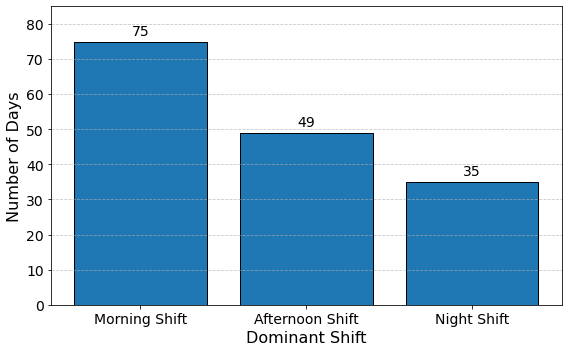

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Detect the repository root
current_dir = Path.cwd()

if (current_dir / "data").exists():
    repository_root = current_dir
elif (current_dir.parent / "data").exists():
    repository_root = current_dir.parent
else:
    raise FileNotFoundError(
        "The repository data directory could not be found. "
        "Run the notebook from the repository root or from the notebooks directory."
    )

# Dataset path
data_path = repository_root / "data" / "Dataset_Consumo_Shifts_v2.xlsx"

# Verify that the dataset exists
if not data_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Place 'Dataset_Consumo_Shifts_v2.xlsx' "
        "inside the repository data directory."
    )

# Load the dataset
df = pd.read_excel(data_path)

# Verify the required column
required_column = "Dominant Shift"

if required_column not in df.columns:
    raise KeyError(
        f"The dataset must contain a column named '{required_column}'."
    )

# Remove rows without a dominant-shift classification
df = df[df[required_column].notna()].copy()

# Define the logical order of the shifts
shift_order = [
    "Morning Shift",
    "Afternoon Shift",
    "Night Shift"
]

# Count the number of days assigned to each dominant shift
shift_counts = (
    df[required_column]
    .value_counts()
    .reindex(shift_order, fill_value=0)
)

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    shift_counts.index,
    shift_counts.values,
    edgecolor="black"
)

# Add the numerical value above each bar
for bar, value in zip(bars, shift_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        str(int(value)),
        ha="center",
        va="bottom",
        fontsize=14
    )

# Axis labels and formatting
ax.set_xlabel("Dominant Shift", fontsize=16)
ax.set_ylabel("Number of Days", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.set_ylim(0, 85)
ax.grid(True, axis="y", linestyle="--", alpha=0.7)

fig.tight_layout()
plt.show()